<a href="https://colab.research.google.com/github/Gurirath/VIT---EDA---Projects---Classwork--25BAI0153/blob/main/Dataset_Prep_And_EDA__LabWork_25BAI0153.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# --- Course Data Preparation ---
df1SE = pd.DataFrame({
    'StudentID': [9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29],
    'ScoreSE' : [22, 66, 31, 51, 71, 91, 56, 32, 52, 73, 92]
})
df2SE = pd.DataFrame({
    'StudentID': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30],
    'ScoreSE': [98, 93, 44, 77, 69, 56, 31, 53, 78, 93, 56, 77, 33, 56, 27]
})

df1ML = pd.DataFrame({
    'StudentID': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29],
    'ScoreML' : [39, 49, 55, 77, 52, 86, 41, 77, 73, 51, 86, 82, 92, 23, 49]
})
df2ML = pd.DataFrame({
    'StudentID': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
    'ScoreML': [93, 44, 78, 97, 87, 89, 39, 43, 88, 78]
})

# Combine SE and ML data
dfSE = pd.concat([df1SE, df2SE], ignore_index=True)
dfML = pd.concat([df1ML, df2ML], ignore_index=True)

# Answer Department Questions
total_students = pd.concat([dfSE['StudentID'], dfML['StudentID']]).nunique()
se_only = dfSE[~dfSE['StudentID'].isin(dfML['StudentID'])]
ml_only = dfML[~dfML['StudentID'].isin(dfSE['StudentID'])]

print(f"Total unique students: {total_students}")
print(f"Students only in SE: {len(se_only)}")
print(f"Students only in ML: {len(ml_only)}")

Total unique students: 30
Students only in SE: 5
Students only in ML: 4


In [2]:
import pandas as pd
import numpy as np

# --- Reshaping with Hierarchical Indexing ---
data = np.arange(15).reshape((3, 5))
indexers = ['Rainfall', 'Humidity', 'Wind']
dframe1 = pd.DataFrame(data, index=indexers, columns=['Bergen', 'Oslo', 'Trondheim', 'Stavanger', 'Kristiansand'])

print("Original DataFrame:")
display(dframe1)

# Stacking the DataFrame
stacked = dframe1.stack()
print("\nStacked Series (Hierarchical Index):")
display(stacked)

# Unstacking back to DataFrame
print("\nUnstacked back to DataFrame:")
display(stacked.unstack())

# --- Concatenating Series with Keys ---
series1 = pd.Series([0, 111, 222, 333], index=['zeros', 'ones', 'twos', 'threes'])
series2 = pd.Series([444, 555, 666], index=['fours', 'fives', 'sixs'])

frame2 = pd.concat([series1, series2], keys=['Number1', 'Number2'])
print("\nConcatenated Series with keys:")
display(frame2)

print("\nUnstacked Concatenation:")
display(frame2.unstack())

Original DataFrame:


,Bergen,Oslo,Trondheim,Stavanger,Kristiansand
Rainfall,0,1,2,3,4
Humidity,5,6,7,8,9
Wind,10,11,12,13,14



Stacked Series (Hierarchical Index):


Rainfall  Bergen           0
          Oslo             1
          Trondheim        2
          Stavanger        3
          Kristiansand     4
Humidity  Bergen           5
          Oslo             6
          Trondheim        7
          Stavanger        8
          Kristiansand     9
Wind      Bergen          10
          Oslo            11
          Trondheim       12
          Stavanger       13
          Kristiansand    14
dtype: int64


Unstacked back to DataFrame:


,Bergen,Oslo,Trondheim,Stavanger,Kristiansand
Rainfall,0,1,2,3,4
Humidity,5,6,7,8,9
Wind,10,11,12,13,14



Concatenated Series with keys:


Number1  zeros       0
         ones      111
         twos      222
         threes    333
Number2  fours     444
         fives     555
         sixs      666
dtype: int64


Unstacked Concatenation:


,fives,fours,ones,sixs,threes,twos,zeros
Number1,NaN,NaN,111.0,NaN,333.0,222.0,0.0
Number2,555.0,444.0,NaN,666.0,NaN,NaN,NaN


In [4]:
import pandas as pd

# --- New Custom Dataset
df1Phys = pd.DataFrame({
    'StudentID': [101, 102, 103, 104, 105],
    'ScorePhys' : [85, 90, 78, 92, 88]
})
df2Phys = pd.DataFrame({
    'StudentID': [106, 107, 108, 109, 110],
    'ScorePhys': [70, 75, 82, 65, 95]
})

df1Chem = pd.DataFrame({
    'StudentID': [104, 105, 106, 107, 111, 112],
    'ScoreChem' : [80, 81, 79, 88, 91, 87]
})

# Combine the new dataframes
dfPhys = pd.concat([df1Phys, df2Phys], ignore_index=True)
dfChem = df1Chem.copy()

# Calculate totals based on the new manipulated values
total_unique = pd.concat([dfPhys['StudentID'], dfChem['StudentID']]).nunique()
phys_only = dfPhys[~dfPhys['StudentID'].isin(dfChem['StudentID'])]
chem_only = dfChem[~dfChem['StudentID'].isin(dfPhys['StudentID'])]
both = dfPhys[dfPhys['StudentID'].isin(dfChem['StudentID'])]

print("--- Analysis of Manipulated Data (100-series IDs) ---")
print(f"Total unique students in this entry: {total_unique}")
print(f"Students who took only Physics: {len(phys_only)}")
print(f"Students who took only Chemistry: {len(chem_only)}")
print(f"Students who took both subjects: {len(both)}")

print("\nSummary of Students in both subjects:")
display(both.merge(dfChem, on='StudentID'))

--- Analysis of Manipulated Data (100-series IDs) ---
Total unique students in this entry: 12
Students who took only Physics: 6
Students who took only Chemistry: 2
Students who took both subjects: 4

Summary of Students in both subjects:


,StudentID,ScorePhys,ScoreChem
0,104,92,80
1,105,88,81
2,106,70,79
3,107,75,88


In [5]:
print("--- Data Overview: Physics ---")
print(dfPhys.info())
display(dfPhys.describe())

print("\n--- Data Overview: Chemistry ---")
print(dfChem.info())
display(dfChem.describe())

# Check for any null values in the sets
print("\nMissing values in Physics:")
print(dfPhys.isnull().sum())

print("\nMissing values in Chemistry:")
print(dfChem.isnull().sum())

# Correlation between scores for students who took both
both_df = dfPhys.merge(dfChem, on='StudentID')
print("\nCorrelation between Physics and Chemistry scores (for overlapping students):")
display(both_df[['ScorePhys', 'ScoreChem']].corr())

--- Data Overview: Physics ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   StudentID  10 non-null     int64
 1   ScorePhys  10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes
None


,StudentID,ScorePhys
count,10.00000,10.000000
mean,105.50000,82.000000
std,3.02765,9.865766
min,101.00000,65.000000
25%,103.25000,75.750000
50%,105.50000,83.500000
75%,107.75000,89.500000
max,110.00000,95.000000



--- Data Overview: Chemistry ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   StudentID  6 non-null      int64
 1   ScoreChem  6 non-null      int64
dtypes: int64(2)
memory usage: 228.0 bytes
None


,StudentID,ScoreChem
count,6.000000,6.000000
mean,107.500000,84.333333
std,3.271085,4.966555
min,104.000000,79.000000
25%,105.250000,80.250000
50%,106.500000,84.000000
75%,110.000000,87.750000
max,112.000000,91.000000



Missing values in Physics:
StudentID    0
ScorePhys    0
dtype: int64

Missing values in Chemistry:
StudentID    0
ScoreChem    0
dtype: int64

Correlation between Physics and Chemistry scores (for overlapping students):


,ScorePhys,ScoreChem
ScorePhys,1.000000,-0.250356
ScoreChem,-0.250356,1.000000


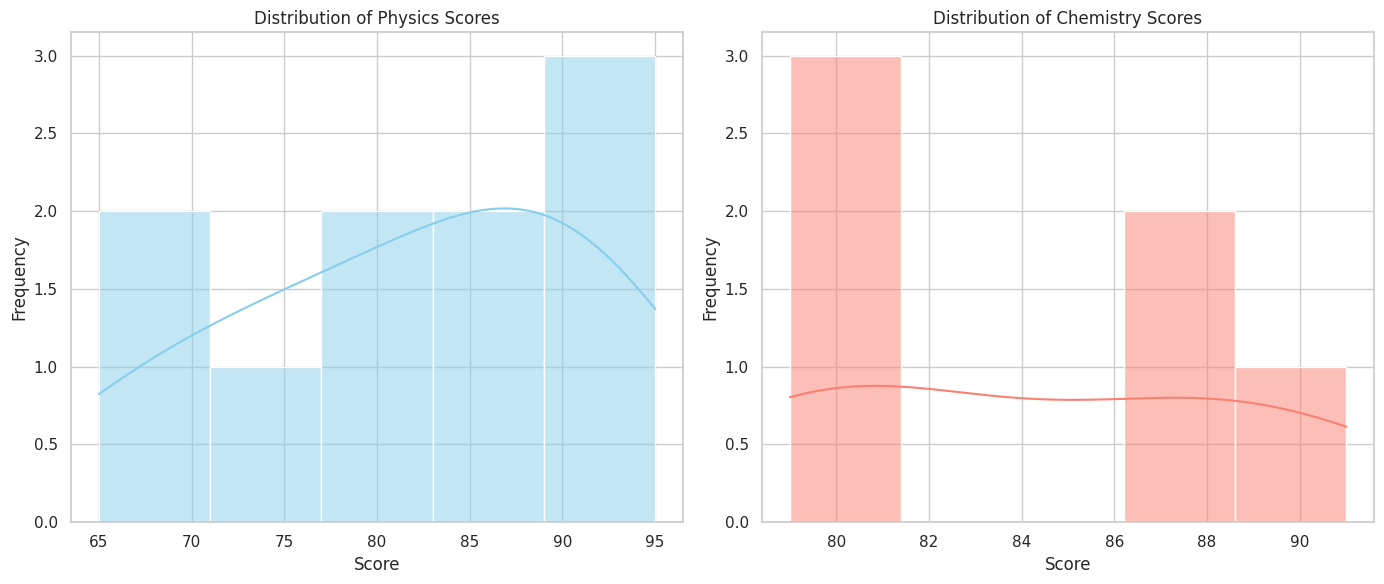

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram for Physics Scores
sns.histplot(dfPhys['ScorePhys'], bins=5, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Physics Scores')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')

# Histogram for Chemistry Scores
sns.histplot(dfChem['ScoreChem'], bins=5, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Chemistry Scores')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

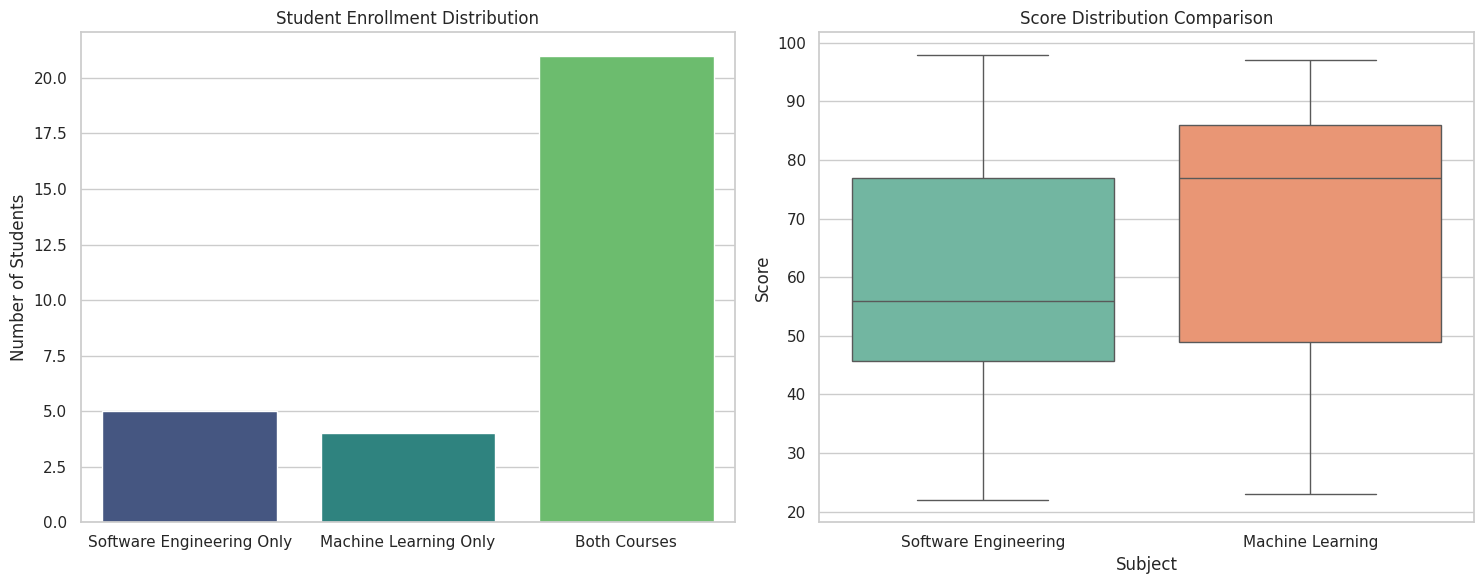

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for category comparison
both_ids = set(dfSE['StudentID']) & set(dfML['StudentID'])
se_only_ids = set(dfSE['StudentID']) - both_ids
ml_only_ids = set(dfML['StudentID']) - both_ids

counts = {
    'Software Engineering Only': len(se_only_ids),
    'Machine Learning Only': len(ml_only_ids),
    'Both Courses': len(both_ids)
}

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Bar plot for student distribution
sns.barplot(x=list(counts.keys()), y=list(counts.values()), ax=axes[0], palette='viridis', hue=list(counts.keys()), legend=False)
axes[0].set_title('Student Enrollment Distribution')
axes[0].set_ylabel('Number of Students')

# 2. Boxplot for Score Distributions
# Combine data for boxplot
scores_se = pd.DataFrame({'Score': dfSE['ScoreSE'], 'Subject': 'Software Engineering'})
scores_ml = pd.DataFrame({'Score': dfML['ScoreML'], 'Subject': 'Machine Learning'})
combined_scores = pd.concat([scores_se, scores_ml])

sns.boxplot(data=combined_scores, x='Subject', y='Score', ax=axes[1], palette='Set2', hue='Subject', legend=False)
axes[1].set_title('Score Distribution Comparison')

plt.tight_layout()
plt.show()